In [86]:
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import pandas as pd
import json
from pathlib import Path
from tqdm import tqdm
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from src.training.model import get_model
from src.training.transforms import get_val_transforms
from src.training.dataloader import get_dataloader

In [87]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
SAMPLE_DIR = PROJECT_ROOT / "src" / "interface" / "samples"
MODEL_DIR = PROJECT_ROOT / "checkpoints"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"

try:
    with open(SPLITS_DIR / 'splits.json', 'r') as f:
        splits = json.load(f)

    eval_set = splits['test']
    device = torch.device("cpu")
    print(f"Training on: {device}")
    checkpoint = torch.load(MODEL_DIR / "best_model.pth", map_location=device)
    model = get_model().to(device)
    model.load_state_dict(checkpoint["model"])
    model.eval()
    print("Model loaded successfully")
except Exception as e:
    print(f"Error: {e}")


Training on: cpu
Model loaded successfully


In [88]:
test_dataloader = get_dataloader(DATA_DIR, eval_set, get_val_transforms())
print(len(test_dataloader.dataset))

188


/Users/andrewfranco/Documents/JetBrains/Pycharm/ brats-tumor-segmentation/.venv/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [89]:
dice_wt = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)
dice_tc = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)
dice_et = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)
hd_wt = HausdorffDistanceMetric(include_background=False, reduction="mean", get_not_nans=False, percentile=95)
hd_tc = HausdorffDistanceMetric(include_background=False, reduction="mean", get_not_nans=False, percentile=95)
hd_et = HausdorffDistanceMetric(include_background=False, reduction="mean", get_not_nans=False, percentile=95)
dice_scores = []
hd_scores = []

for batch in tqdm(test_dataloader):
    # Check if the current batch is completely empty and skip if it is
    if batch is None:
        continue

    with torch.no_grad():
        # Instantiate image and label training data and send it to the device
        image = batch["image"]
        label = batch["label"]
        image = image.to(device)
        label = label.to(device)

        # Run sliding window inference
        output = sliding_window_inference(image, roi_size=(128, 128, 128), sw_batch_size=1, predictor=model)

        # Get model output
        model_output = torch.softmax(output, dim=1)
        model_output = torch.argmax(model_output, dim=1, keepdim=True)

        # WT = labels 1, 2, 3
        pred_wt = (model_output >= 1).float()
        label_wt = (label >= 1).float()

        # TC = labels 1, 3
        pred_tc = ((model_output == 1) | (model_output == 3)).float()
        label_tc = ((label == 1) | (label == 3)).float()

        # ET = label 3 only
        pred_et = (model_output == 3).float()
        label_et = (label == 3).float()

        # Calculate dice scores for each case
        dice_wt(y_pred=pred_wt, y=label_wt)
        hd_wt(y_pred=pred_wt, y=label_wt)
        dice_tc(y_pred=pred_tc, y=label_tc)
        hd_tc(y_pred=pred_tc, y=label_tc)
        dice_et(y_pred=pred_et, y=label_et)
        hd_et(y_pred=pred_et, y=label_et)

        calculated_wt_dice = dice_wt.aggregate().item()
        calculated_wt_hd = hd_wt.aggregate().item()
        calculated_tc_dice = dice_tc.aggregate().item()
        calculated_tc_hd = hd_tc.aggregate().item()
        calculated_et_dice = dice_et.aggregate().item()
        calculated_et_hd = hd_et.aggregate().item()

        batch_dice = {"wt":calculated_wt_dice, "tc": calculated_tc_dice, "et":calculated_et_dice}
        batch_hd = {"wt":calculated_wt_hd, "tc": calculated_tc_hd, "et":calculated_et_hd}
        dice_scores.append(batch_dice)
        hd_scores.append(batch_hd)

        dice_wt.reset()
        hd_wt.reset()
        dice_tc.reset()
        hd_tc.reset()
        dice_et.reset()
        hd_et.reset()

  0%|          | 0/188 [00:00<?, ?it/s]/Users/andrewfranco/Documents/JetBrains/Pycharm/ brats-tumor-segmentation/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/andrewfranco/Documents/JetBrains/Pycharm/ brats-tumor-segmentation/.venv/lib/python3.11/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/Users/andrewfranco/Documents/JetBrains/Pycharm/ brats-tumor-seg

In [94]:
dice_df = pd.DataFrame(dice_scores)
hd_df = pd.DataFrame(hd_scores)
print(dice_df)
print(hd_df)

           wt        tc        et
0    0.968726  0.978459  0.953951
1    0.979582  0.978833  0.936179
2    0.970289  0.936266  0.923257
3    0.980193  0.951660  0.939835
4    0.964103  0.958301  0.931118
..        ...       ...       ...
183  0.959162  0.977949  0.958794
184  0.861882  0.928496  0.846042
185  0.919599  0.978769  0.928408
186  0.929146  0.942131  0.892072
187  0.968334  0.933264  0.934211

[188 rows x 3 columns]
            wt        tc        et
0     1.414214  1.000000  1.000000
1     1.000000  1.000000  2.449490
2     1.414214  2.236068  2.449490
3     1.000000  2.236068  1.414214
4     1.414214  1.000000  1.000000
..         ...       ...       ...
183   2.449490  1.414214  1.000000
184  21.679483  1.414214  1.414214
185   3.162278  1.000000  1.000000
186   3.000000  2.828427  2.449490
187   1.414214  3.948281  2.236068

[188 rows x 3 columns]


In [95]:
mean_wt = dice_df['wt'].mean()
mean_tc = dice_df['tc'].mean()
mean_et = dice_df['et'].mean()
std_wt = dice_df['wt'].std()
std_tc = dice_df['tc'].std()
std_et = dice_df['et'].std()
mean_hd_wt = hd_df['wt'].mean()
mean_hd_tc = hd_df['tc'].mean()
mean_hd_et = hd_df['et'].mean()

print(f"Dice Mean\nWT: {mean_wt:.2f} TC: {mean_tc:.2f} ET: {mean_et:.2f}")
print(f"Dice STD\nWT: {std_wt:.2f} TC: {std_tc:.2f} ET: {std_et:.2f}")
print(f"HD Mean\nWT: {mean_hd_wt:.2f} TC: {mean_hd_tc:.2f} ET: {mean_hd_et:.2f}")

Dice Mean
WT: 0.93 TC: 0.91 ET: 0.85
Dice STD
WT: 0.07 TC: 0.15 ET: 0.21
HD Mean
WT: 5.94 TC: 3.76 ET: 3.23


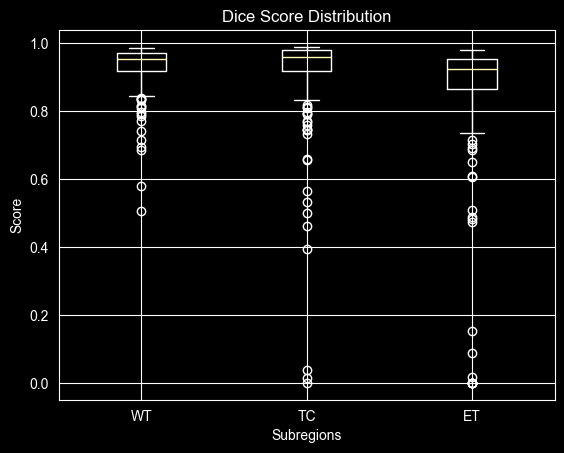

In [92]:
plt.boxplot([dice_df['wt'], dice_df['tc'], dice_df['et']], tick_labels=['WT', 'TC', 'ET'])
plt.title("Dice Score Distribution")
plt.ylabel("Score")
plt.xlabel("Subregions")

# Display the plot
plt.show()

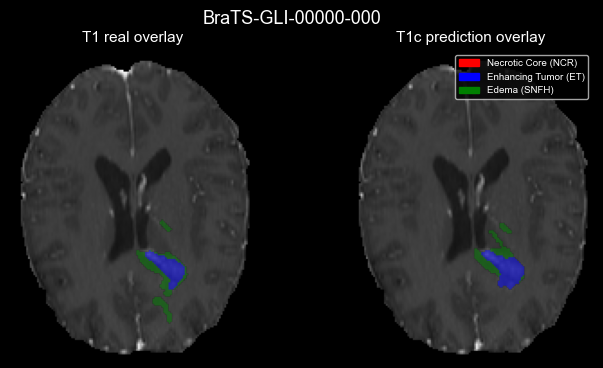

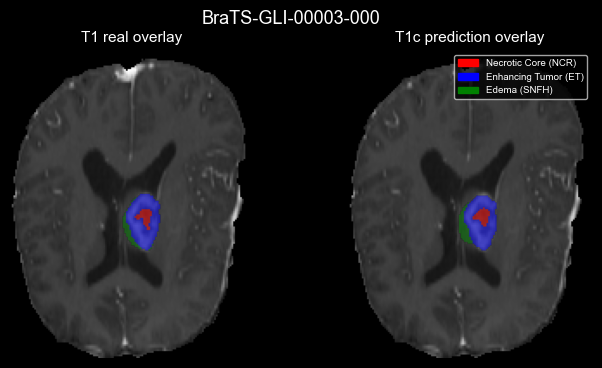

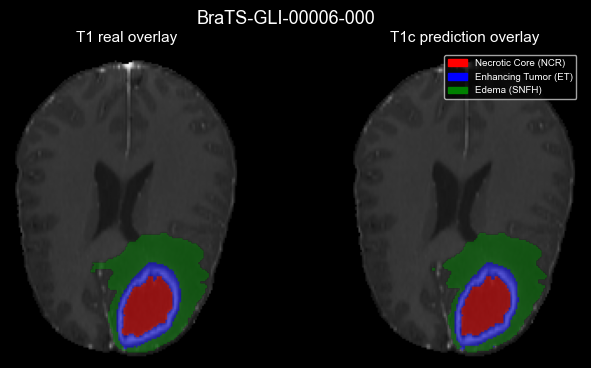

In [93]:
cases = ["BraTS-GLI-00000-000", 'BraTS-GLI-00003-000', 'BraTS-GLI-00006-000']

for case in cases:
    t1c_path =  SAMPLE_DIR / case / f"{case}-t1c.nii.gz"
    real_seg_path = DATA_DIR / case / f"{case}-seg.nii.gz"
    pred_seg_path = SAMPLE_DIR / case / f"{case}-seg.nii.gz"
    t1c = nib.load(str(t1c_path))
    real_seg = nib.load(str(real_seg_path))
    pred_seg = nib.load(str(pred_seg_path))
    mid_idx = int(t1c.shape[2] // 1.7)

    # Get the middle axial slice of the segmentation map
    real_seg_slice = real_seg.get_fdata()[:, :, mid_idx].T
    pred_seg_slice = pred_seg.get_fdata()[:, :, mid_idx].T

    # Create a color overlay
    real_overlay = np.zeros((*real_seg_slice.shape, 4))
    pred_overlay = np.zeros((*real_seg_slice.shape, 4))
    color_map = {1:"red", 2:"green", 3:"blue"}

    # Overlay the segmentation map with colors
    for label, color in color_map.items():
        real_overlay[real_seg_slice == label, :] = to_rgba(color, alpha=0.5)
        pred_overlay[pred_seg_slice == label, :] = to_rgba(color, alpha=0.5)

    # Create a figure with the segmentation map and overlay
    seg_overlay, axis = plt.subplots(1, 2, figsize=(8, 4))
    seg_overlay.suptitle(case, fontsize=13)

    axis[0].imshow(t1c.get_fdata()[:, :, mid_idx].T, cmap="gray", origin="lower")
    axis[0].set_title("T1 real overlay", fontsize=11)
    axis[0].imshow(real_overlay, origin="lower")
    axis[0].axis("off")
    axis[1].imshow(t1c.get_fdata()[:, :, mid_idx].T, cmap="gray", origin="lower")
    axis[1].imshow(pred_overlay, origin="lower")
    axis[1].set_title("T1c prediction overlay", fontsize=11)
    axis[1].axis("off")

    # Add legend with colors
    legend = [
        mpatches.Patch(color="red", label="Necrotic Core (NCR)"),
        mpatches.Patch(color="blue", label="Enhancing Tumor (ET)"),
        mpatches.Patch(color="green", label="Edema (SNFH)")]

    plt.legend(handles=legend, loc="upper right", fontsize=7)

## Evaluation Results

Metrics computed on 188 BraTS 2023 GLI test cases using standard image-level Dice and Hausdorff95.

### Quantitative Results

| Model                         | WT Dice | TC Dice | ET Dice | WT HD95 (mm) | TC HD95 (mm) | ET HD95 (mm) |
|-------------------------------|---|---|---|---|---|---|
| **This Model (3D U-Net)**     | **0.930** | **0.910** | **0.848** | **5.94** | **3.76** | **3.23** |
| BraTS 2023 Winner (ensemble)† | 0.901 | 0.867 | 0.851 | 14.94 | 14.47 | 17.70 |
| KLE-based SOTA (2024)†        | 0.929 | — | — | 2.93 | 6.78 | 10.35 |

† Challenge entries report lesion-wise metrics, which penalize missed lesions and false positives,
resulting in lower scores than standard image-level metrics used here. Direct comparison should
be interpreted with this distinction in mind.

### Score Distribution
![Dice Score Distribution](./figures/dice_boxplot.png)

### Qualitative Results
Ground truth vs. predicted segmentation overlays for representative test cases.
Regions shown: Necrotic Core (red), Enhancing Tumor (blue), Edema (green).